In [15]:
from pymongo import MongoClient
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Konfigurasi visualisasi
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [16]:
try:
    # 1. Koneksi
    client = MongoClient("mongodb://localhost:27017/")
    db = client["cookcash_db"]
    collection = db["resep"]

    # 2. Ambil data dan ubah jadi DataFrame
    df_train = pd.DataFrame(list(collection.find()))

    # 3. Hapus kolom '_id' bawaan MongoDB
    if not df_train.empty and '_id' in df_train.columns:
        df_train.drop(columns=['_id'], inplace=True)

    print(f" Sukses konek! Berhasil narik {len(df_train)} data dari MongoDB.")
    display(df_train.head(3))

except Exception as e:
    print(f" Gagal narik data! Error: {e}")

 Sukses konek! Berhasil narik 9275 data dari MongoDB.


,Title Cleaned,Ingredients Cleaned,Steps,Loves,Category,Total Ingredients,Total Steps
0,udang bakar,"udang , bumbu oles , bawang merah goreng , baw...",1) Goreng bawang merah dan bawang putih..\n2) ...,12,udang,11,3
1,rendang sapi,"daging sapi empuk , kelapa ambil santan , miny...",1) Haluskan semua bumbu halus. Tumis semua bum...,11,sapi,19,4
2,dory tepung crispy,"ikan dory , bawang putih halus , kaldu jamur ,...","1) Potong ikan dory sesuai selera,cuci bersih....",8,ikan,9,8


--- 2. ANALISIS UNIVARIATE ---


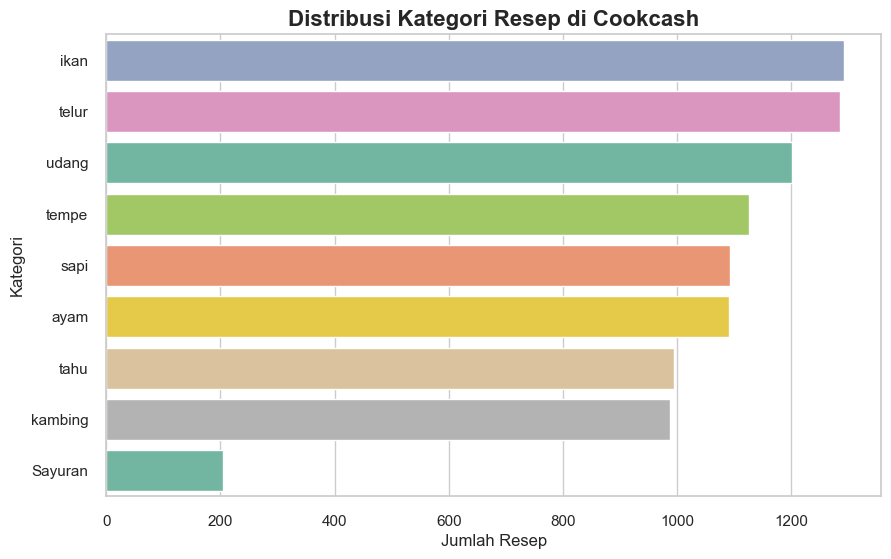

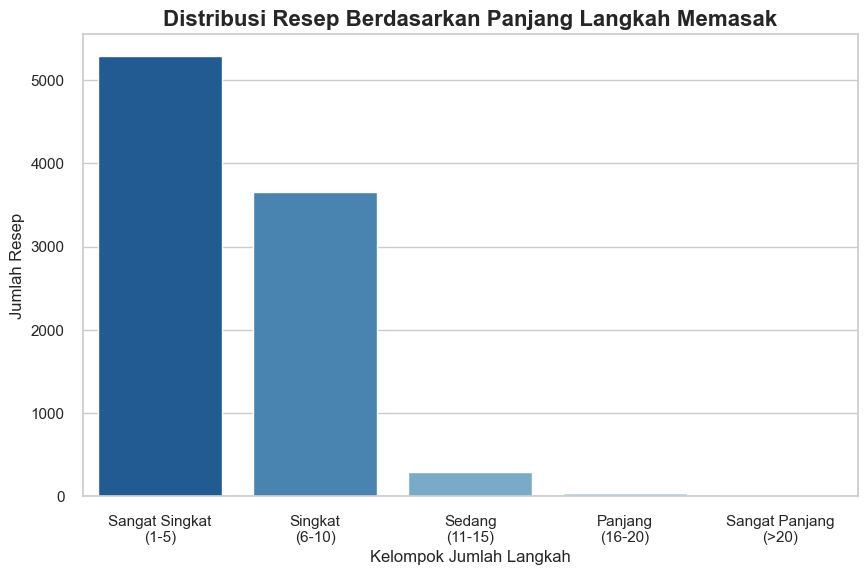

In [19]:
print("--- 2. ANALISIS UNIVARIATE ---")

# Grafik 1: Distribusi Kategori (Bar Chart Mendatar)
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train, y='Category', order=df_train['Category'].value_counts().index, hue='Category', palette='Set2', legend=False)
plt.title('Distribusi Kategori Resep di Cookcash', fontsize=16, weight='bold')
plt.xlabel('Jumlah Resep')
plt.ylabel('Kategori')
plt.show()

# Grafik 2 (PENGGANTI): Kelompok Panjang Langkah (Bar Chart Vertikal)
# 1. Kita buat kolom sementara untuk mengelompokkan jumlah langkah biar rapi
df_train['Kelompok Langkah'] = pd.cut(
    df_train['Total Steps'], 
    bins=[0, 5, 10, 15, 20, 100], 
    labels=['Sangat Singkat\n(1-5)', 'Singkat\n(6-10)', 'Sedang\n(11-15)', 'Panjang\n(16-20)', 'Sangat Panjang\n(>20)']
)

# 2. Tampilkan dalam bentuk Bar Chart
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train, x='Kelompok Langkah', hue='Kelompok Langkah', palette='Blues_r', legend=False)
plt.title('Distribusi Resep Berdasarkan Panjang Langkah Memasak', fontsize=16, weight='bold')
plt.xlabel('Kelompok Jumlah Langkah')
plt.ylabel('Jumlah Resep')
plt.show()

--- 3. ANALISIS BIVARIATE ---


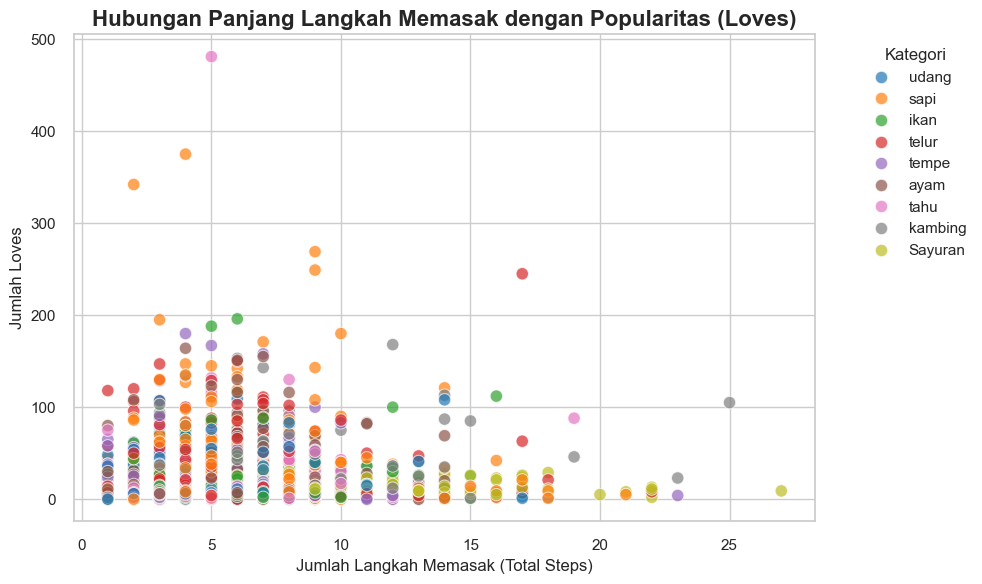

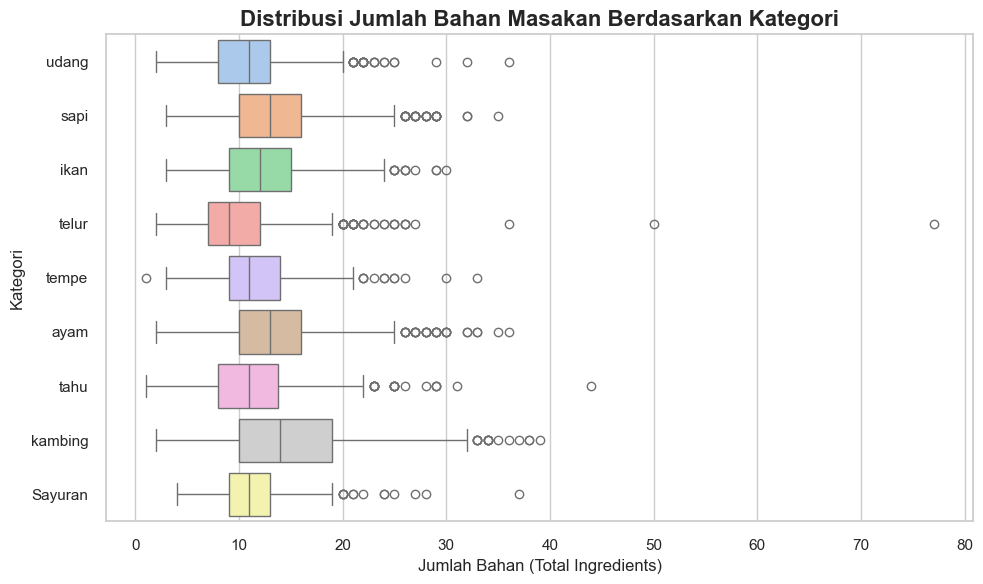

In [21]:
print("--- 3. ANALISIS BIVARIATE ---")

# Grafik 1 (PENGGANTI): Hubungan Jumlah Langkah (Total Steps) vs Popularitas (Loves)
# Menggunakan Scatter Plot (Titik-titik)
plt.figure(figsize=(10, 6))
# Tiap titik adalah 1 resep, warnanya beda tergantung Kategori
sns.scatterplot(data=df_train, x='Total Steps', y='Loves', hue='Category', palette='tab10', alpha=0.7, s=80)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Kategori')
plt.title('Hubungan Panjang Langkah Memasak dengan Popularitas (Loves)', fontsize=16, weight='bold')
plt.xlabel('Jumlah Langkah Memasak (Total Steps)')
plt.ylabel('Jumlah Loves')
plt.tight_layout()
plt.show()

# Grafik 2 (TETAP DIPERTAHANKAN): Boxplot Jumlah Bahan per Kategori
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_train, x='Total Ingredients', y='Category', hue='Category', palette='pastel', legend=False)
plt.title('Distribusi Jumlah Bahan Masakan Berdasarkan Kategori', fontsize=16, weight='bold')
plt.xlabel('Jumlah Bahan (Total Ingredients)')
plt.ylabel('Kategori')
plt.tight_layout()
plt.show()

--- 4. ANALISIS MULTIVARIATE ---


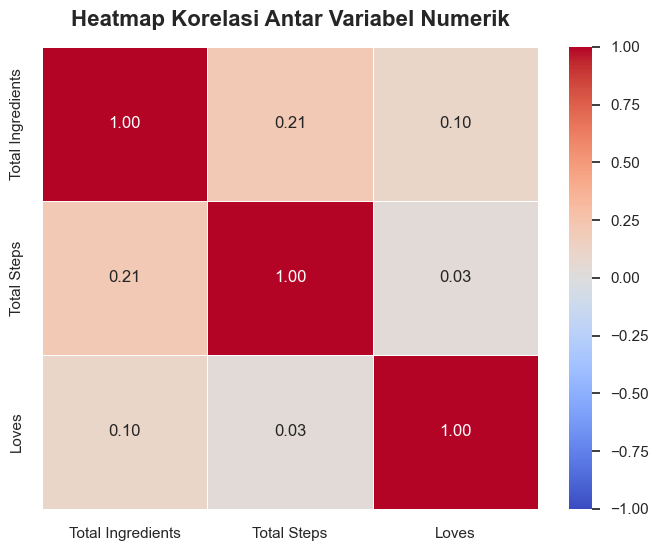

In [22]:
print("--- 4. ANALISIS MULTIVARIATE ---")

# Memilih hanya kolom-kolom yang berisi angka (Numerik)
kolom_angka = ['Total Ingredients', 'Total Steps', 'Loves']
data_korelasi = df_train[kolom_angka].corr()

# Membuat Heatmap
plt.figure(figsize=(8, 6))
# annot=True biar angkanya muncul di dalam kotak, cmap='coolwarm' buat warnanya
sns.heatmap(data_korelasi, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Antar Variabel Numerik', fontsize=16, weight='bold', pad=15)
plt.show()